In [2]:
import pandas as pd
import numpy as np
pd.options.display.float_format = '{:.2f}'.format


import matplotlib.pyplot as plt

from datetime import datetime, date
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/Propsih/test/main/data_test.csv',
    sep=';',
    parse_dates=['VALUE_DAY'], 
    dayfirst=True              
)

df.VALUE_DAY = df.VALUE_DAY.dt.date
df.fillna(0, inplace=True)

df.head()

,CLIENT_ID,VALUE_DAY,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT
0,3596869440,2021-09-30,18.00,8.00,9.00
1,181778433,2021-09-30,7.00,3.00,3.00
2,4271531990,2021-09-30,2.00,0.00,0.00
3,3949165697,2021-09-30,15.00,4.00,5.00
4,1926920317,2021-09-30,3.00,0.00,0.00


Описание полей (названий столбцов): 

•	`CLIENT_ID` - идентификатор клиента; 

•	`VALUE_DAY` - отчетная дата (месяц); 

•	`DIGITAL_30_CNT` - кол-во входов в мобильное приложение за последние 30 дней на отчетную дату; 

•	`TRAN_ACTIVE_30_CNT` - кол-во транзакций в мобильном приложении за последние 30 дней на отчетную дату; 

•	`OPER_ACTIVE_30_CNT` - кол-во операций (транзакции+нефинансовые операции) в мобильном приложении за последние 30 дней на отчетную дату

In [24]:
dfc = df.merge(
     df.groupby('CLIENT_ID')['VALUE_DAY'].transform('min')
    ,left_index=True
    ,right_index=True
    ,suffixes=['_CURRENT', '_FIRST']
).astype({'VALUE_DAY_CURRENT': 'datetime64[ns]', 
          'VALUE_DAY_FIRST': 'datetime64[ns]'})

dfc.VALUE_DAY_CURRENT = dfc.VALUE_DAY_CURRENT.dt.date
dfc.VALUE_DAY_FIRST = dfc.VALUE_DAY_FIRST.dt.date

dfc['just_act'] = 1 * ((dfc['DIGITAL_30_CNT'] > 0) | 
                       (dfc['TRAN_ACTIVE_30_CNT'] > 0) | 
                       (dfc['OPER_ACTIVE_30_CNT'] > 0))
dfc['digital_act'] = 1 * (dfc['DIGITAL_30_CNT'] > 0)
dfc['trans_act'] = 1 * (dfc['TRAN_ACTIVE_30_CNT'] > 0)
dfc['oper_act'] = 1 * (dfc['OPER_ACTIVE_30_CNT'] > 0)

dfc

,CLIENT_ID,VALUE_DAY_CURRENT,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT,VALUE_DAY_FIRST,just_act,digital_act,trans_act,oper_act
0,3596869440,2021-09-30,18.00,8.00,9.00,2021-09-30,1,1,1,1
1,181778433,2021-09-30,7.00,3.00,3.00,2021-09-30,1,1,1,1
2,4271531990,2021-09-30,2.00,0.00,0.00,2021-09-30,1,1,0,0
3,3949165697,2021-09-30,15.00,4.00,5.00,2021-09-30,1,1,1,1
4,1926920317,2021-09-30,3.00,0.00,0.00,2021-09-30,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...
805816,4243322997,2022-02-28,2.00,0.00,0.00,2021-09-30,1,1,0,0
805817,67461867,2022-02-28,3.00,0.00,0.00,2021-09-30,1,1,0,0
805818,302417315,2022-02-28,0.00,0.00,0.00,2021-09-30,0,0,0,0
805819,1780553365,2022-02-28,4.00,0.00,2.00,2022-01-31,1,1,0,1


In [150]:
dfc.groupby('VALUE_DAY_FIRST').CLIENT_ID.nunique()

VALUE_DAY_FIRST
2021-09-30    129232
2021-10-31      7044
2021-11-30      5841
2021-12-31      6875
2022-01-31     14770
2022-02-28      5330
Name: CLIENT_ID, dtype: int64

In [95]:
dfc['client_lines'] = dfc.groupby('CLIENT_ID').CLIENT_ID.transform('count')

dfc[(dfc['client_lines'] < 6) & (dfc['VALUE_DAY_FIRST'] == date(2021, 9, 30))]

,CLIENT_ID,VALUE_DAY_CURRENT,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT,VALUE_DAY_FIRST,just_act,digital_act,trans_act,oper_act,client_lines
5,251791209,2021-09-30,0.00,0.00,0.00,2021-09-30,0,0,0,0,1
8,3412845635,2021-09-30,2.00,0.00,0.00,2021-09-30,1,1,0,0,2
11,2014334517,2021-09-30,0.00,0.00,0.00,2021-09-30,0,0,0,0,1
12,2684280204,2021-09-30,0.00,0.00,0.00,2021-09-30,0,0,0,0,1
15,530713144,2021-09-30,1.00,0.00,0.00,2021-09-30,1,1,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...
805610,1329204448,2022-02-28,0.00,0.00,0.00,2021-09-30,0,0,0,0,5
805623,4232007610,2022-02-28,12.00,7.00,8.00,2021-09-30,1,1,1,1,4
805628,1690295531,2022-02-28,2.00,0.00,0.00,2021-09-30,1,1,0,0,3
805652,491252784,2022-02-28,5.00,0.00,1.00,2021-09-30,1,1,0,1,4


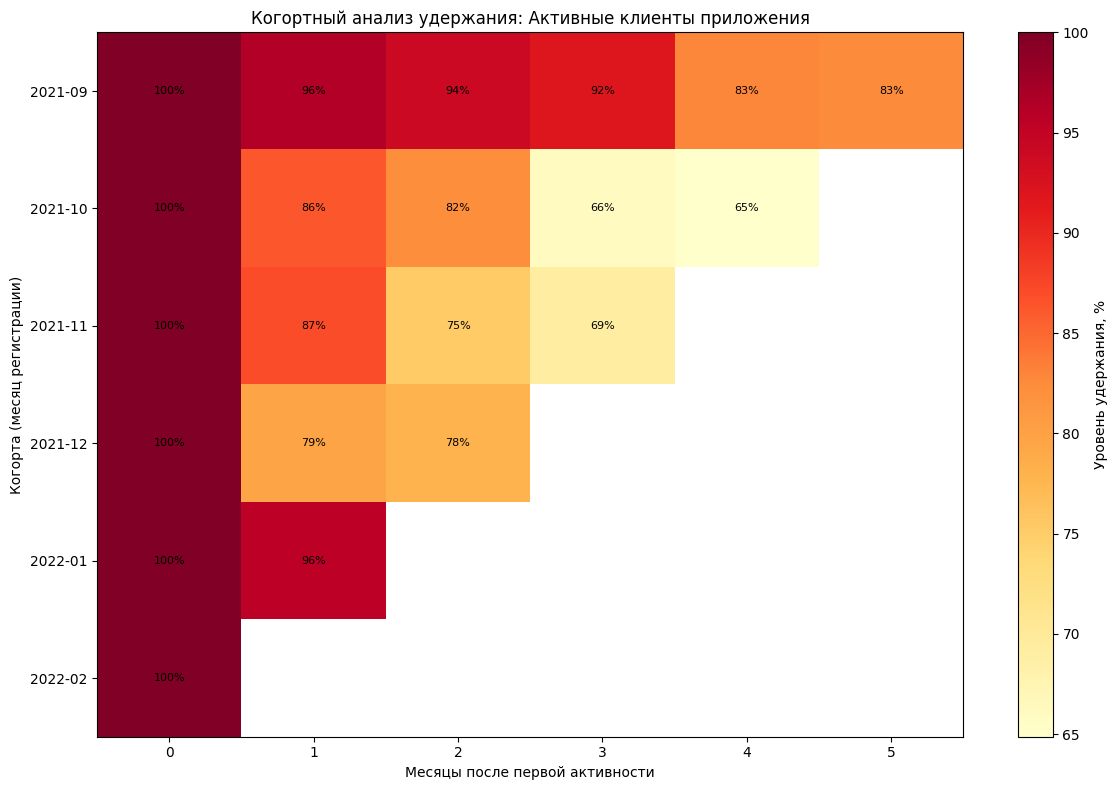

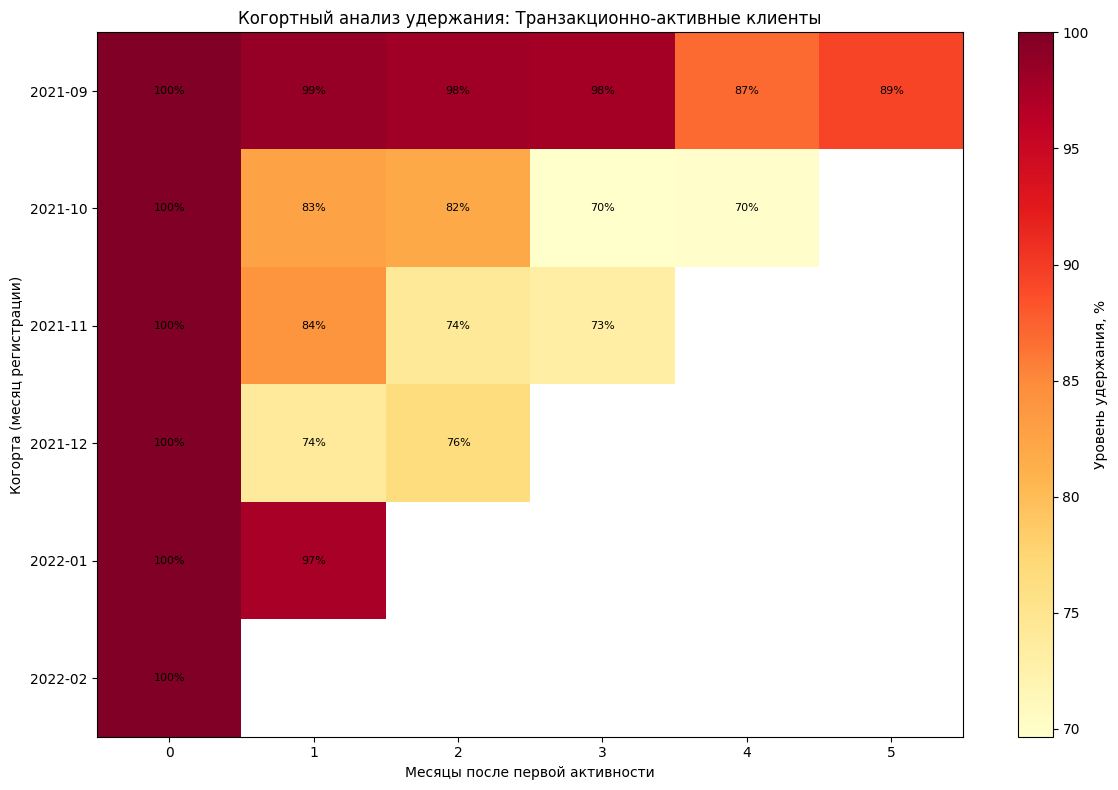

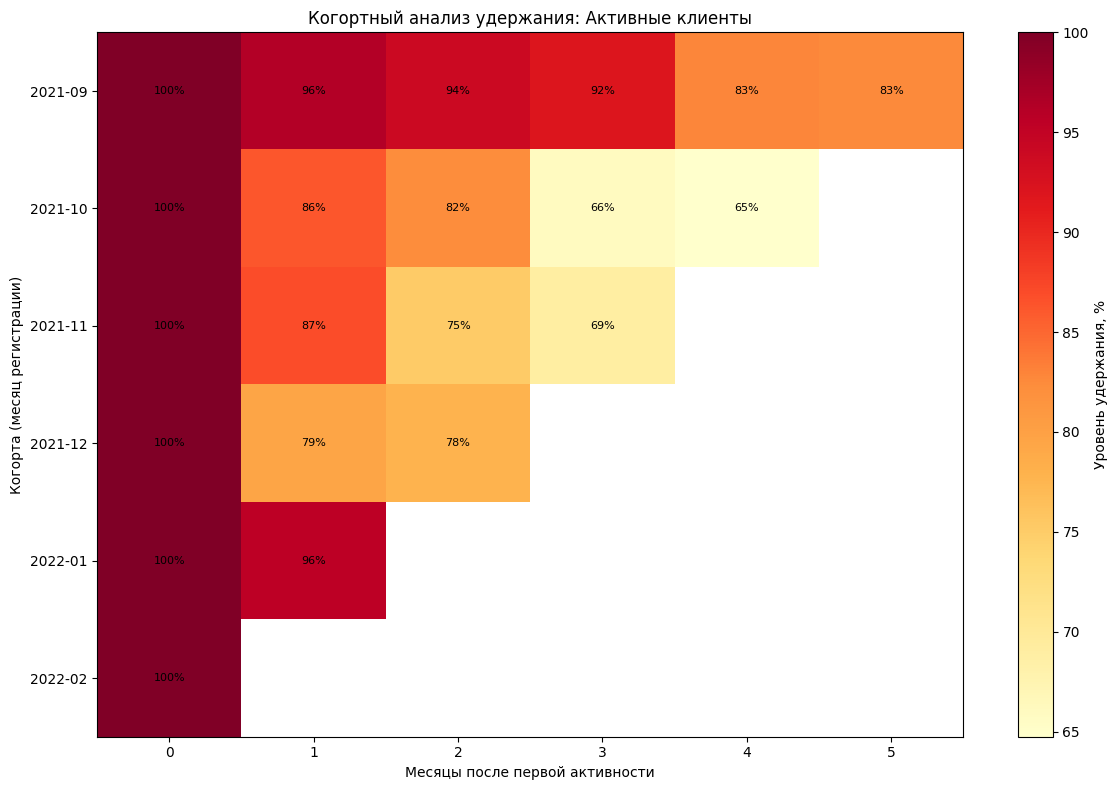

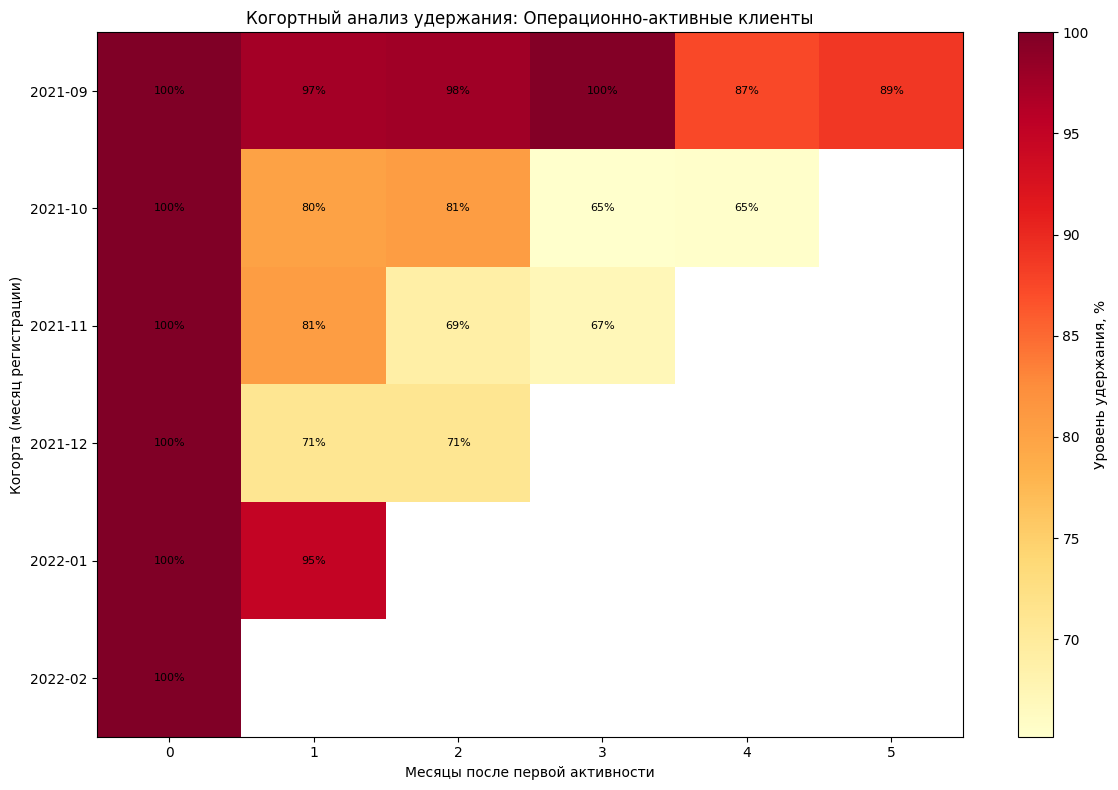

In [107]:
def build_cohort_matrix(df, active_flag, title):

    if isinstance(active_flag, str):
        condition = df[active_flag] == 1
    else:
        condition = active_flag

    df_active = df[condition].copy()

    df_active.VALUE_DAY_CURRENT = pd.to_datetime(df_active.VALUE_DAY_CURRENT)
    df_active.VALUE_DAY_FIRST = pd.to_datetime(df_active.VALUE_DAY_FIRST)

    df_active['cohort_first'] = df_active['VALUE_DAY_FIRST'].dt.to_period('M')
    df_active['cohort_current'] = df_active['VALUE_DAY_CURRENT'].dt.to_period('M')
    df_active['period_index'] = (df_active['cohort_current'] - df_active['cohort_first']).apply(lambda x: x.n)
    
    cohort_data = df_active.groupby(['cohort_first', 'period_index'])['CLIENT_ID'].nunique().reset_index()
    
    cohort_counts = cohort_data.pivot(index='cohort_first', columns='period_index', values='CLIENT_ID')
    cohort_sizes = cohort_counts.iloc[:, 0]
    retention = cohort_counts.divide(cohort_sizes, axis=0) * 100
    
    plt.figure(figsize=(12, 8))
    plt.imshow(retention, aspect='auto', cmap='YlOrRd')
    plt.title(f'Когортный анализ удержания: {title}')
    plt.xlabel('Месяцы после первой активности')
    plt.ylabel('Когорта')
    
    for i in range(retention.shape[0]):
        for j in range(retention.shape[1]):
            value = retention.iloc[i, j]
            if not np.isnan(value):
                plt.text(j, i, f'{value:.0f}%', ha='center', va='center', color='black', fontsize=8)
    
    plt.xticks(np.arange(retention.shape[1]), retention.columns)
    plt.yticks(np.arange(retention.shape[0]), retention.index.astype(str))
    plt.colorbar(label='Уровень удержания, %')
    plt.tight_layout()

    plt.show()

build_cohort_matrix(dfc, 'digital_act', 'Активные клиенты приложения')
build_cohort_matrix(dfc, 'trans_act', 'Транзакционно-активные клиенты')
build_cohort_matrix(dfc, 'just_act', 'Активные клиенты')
build_cohort_matrix(dfc, 'oper_act', 'Операционно-активные клиенты')

### активные клиенты приложения $\rightarrow$

удержание когорты клиентов, что пришли в сентрябре и ранее держится на довольно хорошем уровне и начинает резко падать только спустя три месяца. дело в том, что в данной когорте учитываютяс все лояльные клиенты, что были наработаны банком годам и для которых банк успел стать основным, в отличие от другим когорт, где учитываются только новые клиенты, что еще не успели привыкнуть к продукту. можно отметить, что на дальней дистанции хуже всего себя показала октябрьская когорта, что к январю-февралю потеряла больше трети привлеченных пользователей. связано это в свою очередь это может быть с загруженностью населения временным накопленнием средств перед праздниками

### транзакционно-активные клиенты банка $\rightarrow$

retention также высок, хоть и меньше, чем в случае активных клиентов приложения. спад происходит более планомерно

### активные клиенты банка $\rightarrow$

ситуация в целом повторяет картину активных клиентов приложения. это также видно на линейных графиках, где динамика двух типов клиентов совпадает

### операционно-активные клиенты банка $\rightarrow$

был обнаружен очень интересный случай: retention спустя три месяца вырос до 100%, а после несколько упал. это может свидетельствовать о успешно проведенной маркетинговой кампании и работе с имеющейся клиентской базой. в том числе не стоит отрицать сезонное влияние

In [115]:
import plotly.express as px

# Группируем данные
df_gr = dfc.groupby('VALUE_DAY_CURRENT').agg({
                                        'just_act': 'sum',
                                        'digital_act': 'sum',
                                        'trans_act': 'sum',
                                        'oper_act': 'sum'
                                    }).reset_index()

df_gr['month_year'] = pd.to_datetime(df_gr['VALUE_DAY_CURRENT']).dt.to_period('M').astype(str)

fig = px.bar(
    df_gr,
    x='month_year',  
    y=['just_act', 'digital_act', 'trans_act', 'oper_act'],
    barmode='group',
    title='Активности по месяцам (группированные столбцы)',
    labels={'month_year': 'Месяц', 
            'value': 'Количество активностей', 
            'variable': 'Тип активности'},
)

fig.update_layout(
    legend_title='Тип активности',
    width=1200, 
    height=600
)

fig.show()

df_gr['month_year'] = pd.to_datetime(df_gr['VALUE_DAY_CURRENT']).dt.to_period('M').astype(str)

fig = px.line(
    df_gr,
    x='month_year',  
    y=['just_act', 'digital_act', 'trans_act', 'oper_act'],
    title='Активности по месяцам (группированные столбцы)',
    labels={'month_year': 'Месяц', 
            'value': 'Количество активностей', 
            'variable': 'Тип активности'},
)

fig.update_layout(
    legend_title='Тип активности',
    width=1200, 
    height=600
)

fig.show()

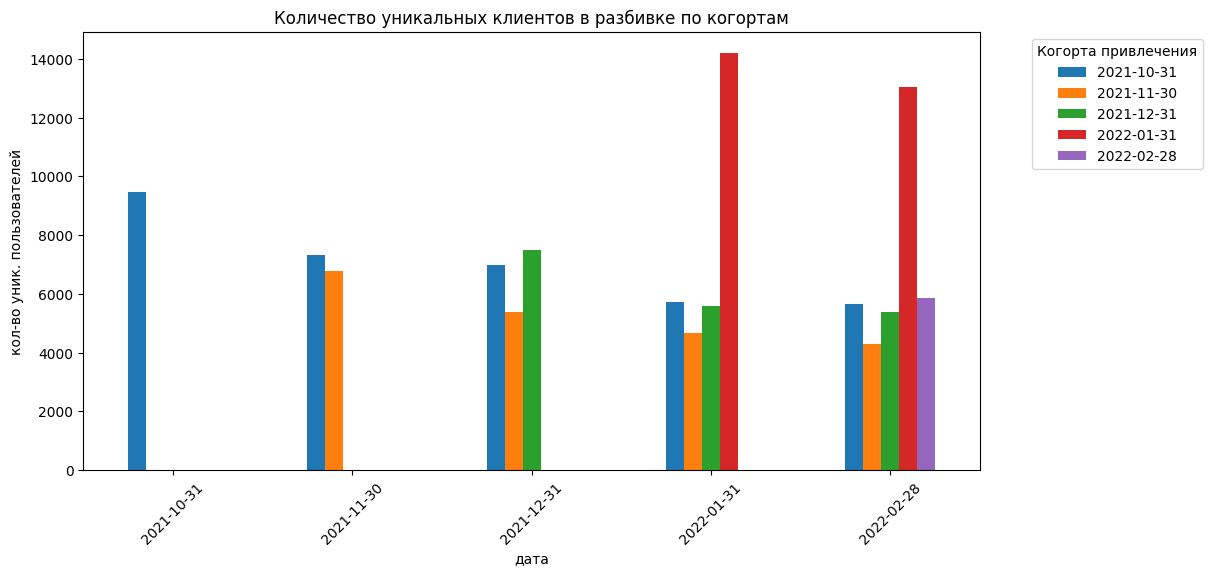

In [114]:
cohort_data = dfc[dfc.VALUE_DAY_FIRST != date(2021, 9, 30)].groupby(['VALUE_DAY_CURRENT', 'VALUE_DAY_FIRST'])['CLIENT_ID'].nunique().unstack().fillna(0)
cohort_data.plot(kind='bar', figsize=(10, 6))

plt.title('Количество уникальных клиентов в разбивке по когортам')
plt.xlabel('дата')
plt.ylabel('кол-во уник. пользователей')
plt.tight_layout()
plt.xticks(rotation=45)
plt.legend(title='Когорта привлечения', bbox_to_anchor=(1.05, 1), loc='upper left');


здесь можно увидеть, что декабрьская когорта разительно отличается от других по величине. связано это с сезонный экономической активностью населения при подготовке к новогодним праздникам.

стоит отметить, что так как мы не имеем информации до сентбря 2021 года, то все клиенты, что были зарегистрированы до этого тоже попадают в данную когорту. ее следует анализировать иначе, нежели чем остальные когорты

In [91]:
# доля транакционно-активных от активных клиентов приложения

df_piv_digit = dfc.pivot_table(index='VALUE_DAY_FIRST', columns='VALUE_DAY_CURRENT', values=['digital_act'], aggfunc='sum')
df_piv_trans = dfc.pivot_table(index='VALUE_DAY_FIRST', columns='VALUE_DAY_CURRENT', values=['trans_act'], aggfunc='sum')

pd.DataFrame(df_piv_trans.values / df_piv_digit.values, columns=df_piv_trans.index, index=df_piv_trans.index).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_FIRST,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,0.694264,0.711050,0.723699,0.738028,0.727980,0.750974
2021-10-31,0.000000,0.655113,0.628214,0.651869,0.691507,0.704934
2021-11-30,0.000000,0.000000,0.646685,0.624060,0.637537,0.685050
2021-12-31,0.000000,0.000000,0.000000,0.670155,0.624676,0.658581
2022-01-31,0.000000,0.000000,0.000000,0.000000,0.731101,0.745775
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.691742


не смотря на сезонные снижения конверсии (постновогодняя экономический застой), можно отметить, что показатель растет во всех когортах с течением времени

__потенциальные гипотезы__ $\rightarrow$

* недостаточно эффективная система лояльности клиентов
    * предположительно стоит построить эксперимент с доп кэшбеком/фишками у партнеров при оплате картой банка/спец предложения для новых клиентов и проверить впоследствии эффективность данной инициативы. предварительно обязательно стоит посчитать предположительную юнит-экономику. так как сам по себе проведение подобного теста может оказаться довольно затратным, стоит ускорить его прокрашивание с помощью методов уменьшения дисперсии, та же статификация идеально здесь подойдет. подходящими метриками в данном случае могут быть конверсии на последних этапах воронки (конверсия в переход на страницу транзакции, конверсия в завершенную транзакцию), также можно смотреть среднее/медианное кол-во транзакций на клиента. как мне кажется еще тут можно использовать прокси-метрику кол-во выданных карт ДК и КК. еще как вариант прокси-метрик можно смотреть на среднее/медианное кол-во целевых действий платажей/переводов, пополнения карт, участия в акции и т.д.

Пополнение счёта/карты: 2–5 раз в месяц.

Использование кэшбэка/акций

* неудобный клиентский путь до транзакции через приложение
    * как вариант можно проверить на эффективность изменение визуального элемента в приложении, либо же в целом пересмотреть визуал страницы транзакций. тут как мне кажется можно смотреть на те же метрики, что и выше

* технические проблемы в приложении
    * если в вашем приложении не работает система уведомлений, хотя вы ее подключали, большой лаг между нажатием на кнопку в приложении и совершением транзакцией, либо же постоянными подвисаниями, то клиетская база постепенно будет утекать. мектрики буду несколько отличаться: 99-ый квантиль времени открытия приложения меньше `n` секунд (легче всего будет проверить бутстратом впоследствии). 


__потенциальный план действий по изменению ситуации__ $\rightarrow$

* пересмотреть клиентский путь в приложении для совершения транзакции
* косметические или же вовсе координальные меры по изменению визуала приложения. выдвижение в более видны места плажек с переводами/акциями партнеров/новыми предложениями партнеров, где можно получить увеличенный кэшбек 
* в случае, если человек использует приложение, но не совершает транзакций, то скорее всего у него есть сторонник продукт банка (депозит/вклад/валютные сбережения и т.д.) и стоит предложить спецпредложение для клиентам с его продуктом. эффективность данной манипуляции также стоит проверить при A/B

In [31]:
# активные клиенты приложения
# активный клиент - хотя бы раз зашел в приложение за отчетный период

dfc[dfc.digital_act == 1].pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='CLIENT_ID', 
    aggfunc=pd.Series.nunique
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,0.873507,0.840295,0.820122,0.802773,0.723985,0.721168
2021-10-31,0.000000,0.909284,0.783930,0.748296,0.600085,0.589864
2021-11-30,0.000000,0.000000,0.916795,0.796953,0.689608,0.633282
2021-12-31,0.000000,0.000000,0.000000,0.917236,0.728582,0.713600
2022-01-31,0.000000,0.000000,0.000000,0.000000,0.909953,0.869262
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.917824


In [32]:
# транзакционно активные клиенты
# транзакционно активный клиент - хотя бы раз зашел совершил транзакцию за отчетный период

dfc[dfc.TRAN_ACTIVE_30_CNT > 0].pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='CLIENT_ID', 
    aggfunc=pd.Series.nunique
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,0.606444,0.597491,0.593522,0.592469,0.527044,0.541576
2021-10-31,0.000000,0.595684,0.492476,0.487791,0.414963,0.415815
2021-11-30,0.000000,0.000000,0.592878,0.497346,0.439651,0.433830
2021-12-31,0.000000,0.000000,0.000000,0.614691,0.455127,0.469964
2022-01-31,0.000000,0.000000,0.000000,0.000000,0.665267,0.648274
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.634897


In [29]:
# stickness для всех представленных клиентов

dfc.pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='DIGITAL_30_CNT', 
    aggfunc='sum'
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,11.054606,10.766009,10.772136,11.805995,9.013120,10.093109
2021-10-31,0.000000,7.122837,6.856374,6.956522,5.384550,5.740080
2021-11-30,0.000000,0.000000,7.395195,8.292600,6.192512,6.677329
2021-12-31,0.000000,0.000000,0.000000,8.598401,7.243704,7.723651
2022-01-31,0.000000,0.000000,0.000000,0.000000,10.755440,12.236673
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,7.911835


в большинстве своем значение 7+, что в целом выше среднего. в какие-то месяцы значения и вовсе становятся 10+, что можно считать довольно хорошим показателем

In [105]:
# медианное кол-во входов в приложение по когортам

dfc.pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='DIGITAL_30_CNT', 
    aggfunc='median'
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,5.000000,5.000000,6.000000,6.000000,5.000000,6.000000
2021-10-31,0.000000,5.000000,4.000000,4.000000,5.000000,5.000000
2021-11-30,0.000000,0.000000,5.000000,4.000000,3.000000,5.000000
2021-12-31,0.000000,0.000000,0.000000,5.000000,4.000000,4.000000
2022-01-31,0.000000,0.000000,0.000000,0.000000,6.000000,7.000000
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000


In [31]:
# среднее кол-во транзакций

dfc.pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='TRAN_ACTIVE_30_CNT', 
    aggfunc='sum'
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,2.971324,3.042317,3.085843,3.323304,2.651243,3.001227
2021-10-31,0.000000,1.596032,1.739130,1.901224,1.542528,1.709688
2021-11-30,0.000000,0.000000,1.714328,2.128685,1.692217,1.865419
2021-12-31,0.000000,0.000000,0.000000,1.941772,1.881812,2.149101
2022-01-31,0.000000,0.000000,0.000000,0.000000,3.019224,3.565031
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,1.974420


In [9]:
dfc.groupby('VALUE_DAY_FIRST')\
    .agg({
         'DIGITAL_30_CNT':      'sum'
        ,'TRAN_ACTIVE_30_CNT':  'sum'
        ,'OPER_ACTIVE_30_CNT':  'sum'
    })

,DIGITAL_30_CNT,TRAN_ACTIVE_30_CNT,OPER_ACTIVE_30_CNT
VALUE_DAY_FIRST,,,
2021-09-30,7192891.00,2047294.00,2815794.00
2021-10-31,303804.00,80438.00,107508.00
2021-11-30,193735.00,50206.00,70289.00
2021-12-31,176861.00,44825.00,64362.00
2022-01-31,326511.00,93503.00,131095.00
2022-02-28,46395.00,11578.00,17393.00


In [10]:
dfc.groupby('VALUE_DAY_FIRST')\
    .agg({
         'DIGITAL_30_CNT':      ['mean', 'median']
        ,'TRAN_ACTIVE_30_CNT':  ['mean', 'median']
        ,'OPER_ACTIVE_30_CNT':  ['mean', 'median']
    })

DIGITAL_30_CNT        TRAN_ACTIVE_30_CNT         \
                          mean median               mean median   
VALUE_DAY_FIRST                                                   
2021-09-30               11.92   7.00               3.39   2.00   
2021-10-31                8.64   4.00               2.29   1.00   
2021-11-30                9.16   5.00               2.37   1.00   
2021-12-31                9.57   5.00               2.42   1.00   
2022-01-31               11.99   7.00               3.43   2.00   
2022-02-28                7.91   5.00               1.97   1.00   

                OPER_ACTIVE_30_CNT         
                              mean median  
VALUE_DAY_FIRST                            
2021-09-30                    4.67   2.00  
2021-10-31                    3.06   2.00  
2021-11-30                    3.32   2.00  
2021-12-31                    3.48   2.00  
2022-01-31                    4.81   2.00  
2022-02-28                    2.97   2.00

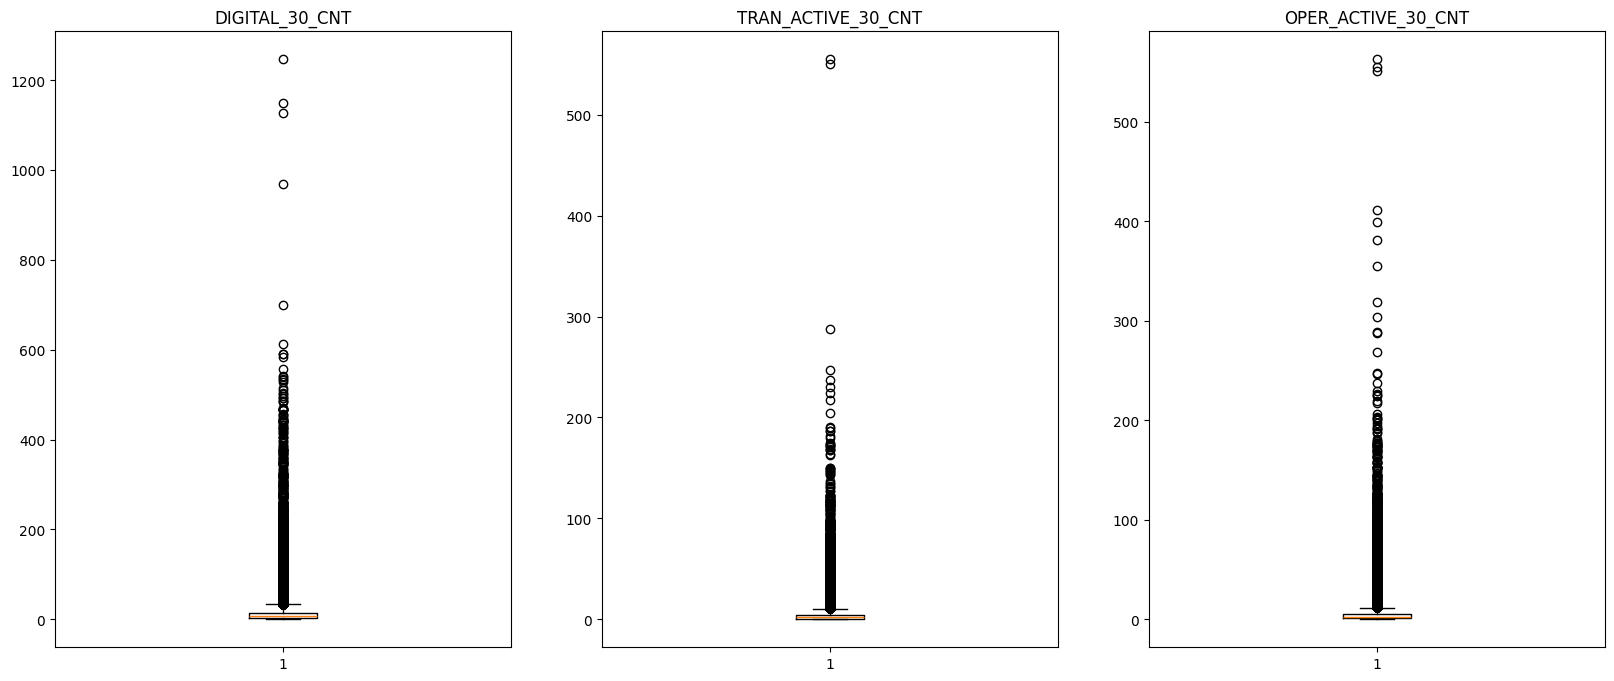

In [53]:
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.boxplot(dfc['DIGITAL_30_CNT'])
plt.title('DIGITAL_30_CNT')

plt.subplot(1, 3, 2)
plt.boxplot(dfc['TRAN_ACTIVE_30_CNT'])
plt.title('TRAN_ACTIVE_30_CNT')

plt.subplot(1, 3, 3)
plt.boxplot(dfc['OPER_ACTIVE_30_CNT'])
plt.title('OPER_ACTIVE_30_CNT');

как можно увидеть выше, кол-во всех трех показатель довольно кучно располагается в промежутке от практически 0 до +/- 200-300, что не передает всей картины. все дело в выбросах, от которых в свою очередь избавиться и посмотреть на большую часть клиентов. к примеру, мы можем отбросить значения больше 95-го квантиля

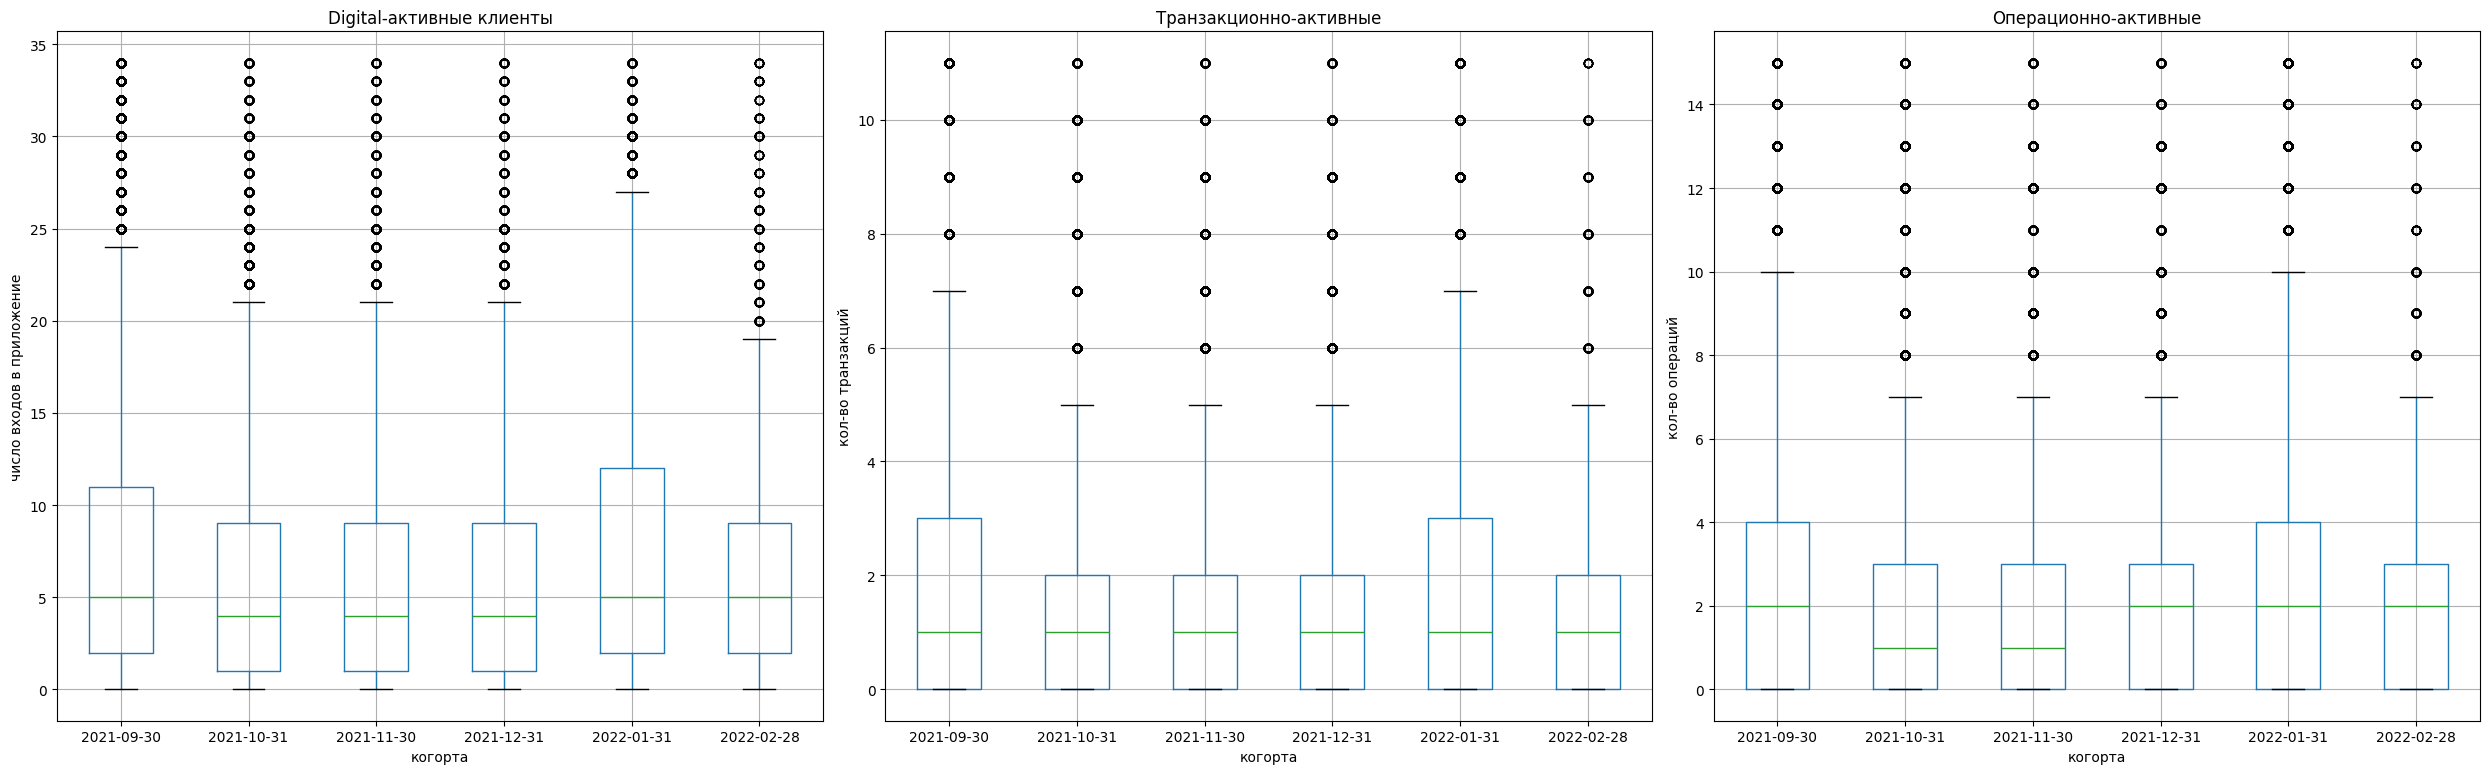

In [149]:
plt.figure(figsize=(25, 8))

plt.subplot(1, 3, 1)
dfc.loc[dfc.DIGITAL_30_CNT < dfc.DIGITAL_30_CNT.quantile(.95)].boxplot(column='DIGITAL_30_CNT', by='VALUE_DAY_FIRST', ax=plt.gca())
plt.title('Digital-активные клиенты', fontsize=12)
plt.xlabel('когорта', fontsize=10)
plt.ylabel('число входов в приложение', fontsize=10)
plt.suptitle('')

plt.subplot(1, 3, 2)
dfc.loc[dfc.TRAN_ACTIVE_30_CNT < dfc.TRAN_ACTIVE_30_CNT.quantile(.95)].boxplot(column='TRAN_ACTIVE_30_CNT', by='VALUE_DAY_FIRST', ax=plt.gca())
plt.title('Транзакционно-активные', fontsize=12)
plt.xlabel('когорта', fontsize=10)
plt.ylabel('кол-во транзакций', fontsize=10)
plt.suptitle('')

plt.subplot(1, 3, 3)
dfc.loc[dfc.OPER_ACTIVE_30_CNT < dfc.OPER_ACTIVE_30_CNT.quantile(.95)].boxplot(column='OPER_ACTIVE_30_CNT', by='VALUE_DAY_FIRST', ax=plt.gca())
plt.title('Операционно-активные', fontsize=12)
plt.xlabel('когорта', fontsize=10)
plt.ylabel('кол-во операций', fontsize=10)
plt.suptitle('')

plt.tight_layout()
plt.show();

здесь уже в свою очередь ситуация раскрывается абсолютно иначе. помимо того, что здесь мы избавились от выбросов с помощью квантилей, так еще дополнительно сделали разбивку по когортам. можем заметить, что, к примеру, квантили клиентов январской когорты везде выбиваются вперед. эта когорта людей, что готовы тратить свои деньги, из-за "сезонного обострения". связано это может быть также с большим наплывом новых клиентов (скорее всего из-за взаимосвязей с партнерами, выгодными новогодними акциями и т.д.). еще как косвенную причину можно упомянуть сохранение уровня процентной ставки на одном уровне.

не смотря на увеличенную digital и операционную активность у более поздних когорт, медианное кол-во транзакций осталось таким же

In [51]:
dfc.groupby(["VALUE_DAY_FIRST", "VALUE_DAY_CURRENT"])["CLIENT_ID"]\
    .nunique()\
    .unstack(fill_value=0)\
    .fillna(0).\
    style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,113265,105936,103154,100491,90529,89891
2021-10-31,0,9476,7319,6997,5716,5656
2021-11-30,0,0,6784,5401,4666,4293
2021-12-31,0,0,0,7505,5588,5394
2022-01-31,0,0,0,0,14201,13041
2022-02-28,0,0,0,0,0,5864


In [118]:
dfc.pivot_table(
    index='VALUE_DAY_FIRST', 
    columns='VALUE_DAY_CURRENT', 
    values='TRAN_ACTIVE_30_CNT', 
    aggfunc='sum'
).div(
    dfc.groupby('VALUE_DAY_FIRST')['CLIENT_ID'].nunique(), axis=0
).fillna(0).style.background_gradient(cmap='viridis', axis=1)

VALUE_DAY_CURRENT,2021-09-30,2021-10-31,2021-11-30,2021-12-31,2022-01-31,2022-02-28
VALUE_DAY_FIRST,,,,,,
2021-09-30,2.971324,3.042317,3.085843,3.323304,2.651243,3.001227
2021-10-31,0.000000,1.596032,1.739130,1.901224,1.542528,1.709688
2021-11-30,0.000000,0.000000,1.714328,2.128685,1.692217,1.865419
2021-12-31,0.000000,0.000000,0.000000,1.941772,1.881812,2.149101
2022-01-31,0.000000,0.000000,0.000000,0.000000,3.019224,3.565031
2022-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,1.974420
